## Imports

In [1]:
import mosaique as mq
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras

2025-01-24 10:55:06.348812: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-24 10:55:06.411000: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-24 10:55:07.351394: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Check GPU installation is working

In [2]:
import tensorflow as tf 
import tensorrt as trt

print(f' tensorflow version {tf.__version__}')

print(f' tensorrt version {trt.__version__}')

print(tf.config.list_physical_devices('GPU'))

 tensorflow version 2.16.1
 tensorrt version 10.7.0.post1
[]


2025-01-24 10:55:08.222188: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:

# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [4]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [5]:
def preset():
    from tensorflow import keras
    mnist_dataset = keras.datasets.fashion_mnist
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("results_fashion_train")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("results_fashion_test")
    #load the data set want to train
    (tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()
    #if you want slice the data for check reasons
    # tr_images = tr_images[:50:]
    # tr_labels = tr_labels[:50]
    # te_images = te_images[:10:]
    # te_labels = te_labels[:10]
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [6]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [7]:
# # not using PorcessPoolExecutor

# for p in permutations:
#     pool(train_images[:,:,p],)

In [8]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

60/60 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step


In [9]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step


In [10]:
from keras.callbacks import CSVLogger

def run(tr_images, te_images, label):
    log_dir = train_layer.name + "/run/"
    log_file =  log_dir + label
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    q_model = keras.models.Sequential([
        keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax")
    ])
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    q_history = q_model.fit(
        tr_images,
        train_labels,
        validation_data=(te_images, test_labels),
        batch_size=128,
        epochs=60,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = csv_logger
    )

def model(variant, tr_layer, te_layer):
    tr_images = tr_layer.open(variant)
    te_images =  te_layer.open(variant)

    label = ''.join(map(str,variant))

    run(tr_images, te_images, label)

(10000, 14, 14, 4)


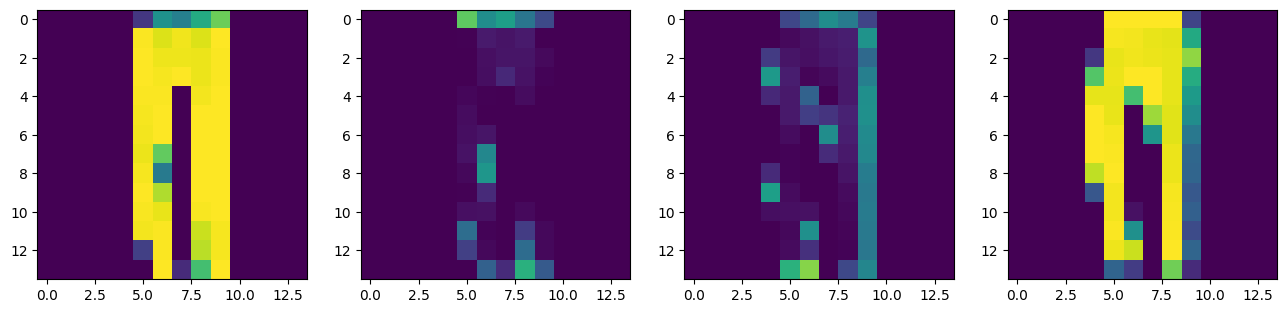

In [11]:
from matplotlib import pyplot as plt

print(test_layer.open([0,1,3,2]).shape)

post = test_layer.open([0,1,3,2])

_min, _max = np.amin(post), np.amax(post)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[c].imshow(post[2,:,:,c],vmin = _min, vmax = _max)

In [12]:

# for j in range(3):
#     with ProcessPoolExecutor(8) as executor:
#         runner = {
#             executor.submit(model,variant = p, tr_layer = train_layer, te_layer= test_layer): p for p in permutations[8*j:8*(j+1)]
#         }
#         for future in as_completed(runner):
#             runner.pop(future)

In [13]:
for ind, variant  in enumerate(permutations):

    label = ''.join(map(str,variant))
    # print(ind, label)
    tr_images = train_layer.open(variant)
    te_images =  test_layer.open(variant)
    run(tr_images,te_images,label)

Epoch 1/60
469/469 - 2s - 3ms/step - accuracy: 0.7628 - loss: 0.6836 - val_accuracy: 0.8039 - val_loss: 0.5466
Epoch 2/60
469/469 - 1s - 2ms/step - accuracy: 0.8242 - loss: 0.4950 - val_accuracy: 0.8204 - val_loss: 0.5063
Epoch 3/60
469/469 - 1s - 2ms/step - accuracy: 0.8368 - loss: 0.4628 - val_accuracy: 0.8226 - val_loss: 0.4901
Epoch 4/60
469/469 - 1s - 2ms/step - accuracy: 0.8436 - loss: 0.4455 - val_accuracy: 0.8229 - val_loss: 0.4849
Epoch 5/60
469/469 - 1s - 2ms/step - accuracy: 0.8471 - loss: 0.4340 - val_accuracy: 0.8284 - val_loss: 0.4836
Epoch 6/60
469/469 - 1s - 2ms/step - accuracy: 0.8465 - loss: 0.4287 - val_accuracy: 0.8293 - val_loss: 0.4741
Epoch 7/60
469/469 - 1s - 2ms/step - accuracy: 0.8506 - loss: 0.4219 - val_accuracy: 0.8297 - val_loss: 0.4753
Epoch 8/60
469/469 - 1s - 2ms/step - accuracy: 0.8511 - loss: 0.4170 - val_accuracy: 0.8287 - val_loss: 0.4738
Epoch 9/60
469/469 - 1s - 2ms/step - accuracy: 0.8528 - loss: 0.4130 - val_accuracy: 0.8312 - val_loss: 0.4731
E

In [14]:
# run the network without filter

run(train_images,test_images,"NO-FILTER")

Epoch 1/60
469/469 - 2s - 5ms/step - accuracy: 0.7784 - loss: 0.6360 - val_accuracy: 0.8195 - val_loss: 0.5177
Epoch 2/60
469/469 - 2s - 4ms/step - accuracy: 0.8356 - loss: 0.4728 - val_accuracy: 0.8258 - val_loss: 0.4863
Epoch 3/60
469/469 - 2s - 3ms/step - accuracy: 0.8453 - loss: 0.4471 - val_accuracy: 0.8317 - val_loss: 0.4764
Epoch 4/60
469/469 - 2s - 4ms/step - accuracy: 0.8491 - loss: 0.4326 - val_accuracy: 0.8321 - val_loss: 0.4757
Epoch 5/60
469/469 - 2s - 3ms/step - accuracy: 0.8534 - loss: 0.4235 - val_accuracy: 0.8386 - val_loss: 0.4566
Epoch 6/60
469/469 - 2s - 4ms/step - accuracy: 0.8547 - loss: 0.4172 - val_accuracy: 0.8333 - val_loss: 0.4672
Epoch 7/60
469/469 - 2s - 3ms/step - accuracy: 0.8571 - loss: 0.4124 - val_accuracy: 0.8391 - val_loss: 0.4545
Epoch 8/60
469/469 - 2s - 4ms/step - accuracy: 0.8573 - loss: 0.4089 - val_accuracy: 0.8364 - val_loss: 0.4557
Epoch 9/60
469/469 - 2s - 4ms/step - accuracy: 0.8599 - loss: 0.4044 - val_accuracy: 0.8373 - val_loss: 0.4580
E

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [15]:
# group the index of the permutation by the symmetry of the filter

diagonal_index = [4, 5, 8, 9, 14, 15, 18, 19]
vertical_index = [0, 1, 6, 7, 16, 17, 22, 23]
horizontal_index = [2, 3, 10, 11, 12, 13, 20, 21]

In [16]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

for ind, variant  in enumerate(permutations):
    label = ''.join(map(str,variant))
    # print(label)
    file = train_layer.name + "/run/" + label
    # print(file)
    
    #read the csv file
    df = pd.read_csv(file)
    
    if ind in diagonal_index:
        diagonal_val_accuracy.append(df['val_accuracy'].tail(30).tolist())
        
    elif ind in vertical_index:
        vertical_val_accuracy.append(df['val_accuracy'].tail(30).tolist())
    
    elif ind in horizontal_index:
        horizontal_val_accuracy.append(df['val_accuracy'].tail(30).tolist())


In [17]:
# need to flatten the list to have all the data in a single list
diagonal_val_accuracy_flattened = [item for sublist in diagonal_val_accuracy for item in sublist]
vertical_val_accuracy_flattened = [item for sublist in vertical_val_accuracy for item in sublist]
horizontal_val_accuracy_flattened = [item for sublist in horizontal_val_accuracy for item in sublist]


In [18]:
file = train_layer.name + "/run/" + "NO-FILTER"
df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(30).tolist()

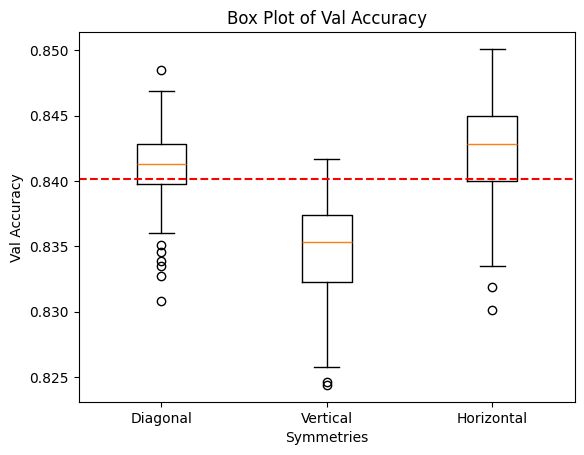

In [19]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal', 'Vertical', 'Horizontal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean No Filter: {mean_no_filter:.2f}')


# Add title and labels
plt.title('Box Plot of Val Accuracy')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')

# Show the plot
plt.show()